### Load a dataset

In [1]:
import pandas as pd
import numpy as np
import visualize_scores as visualize
import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
scores = pd.read_csv("scores_all.csv")

In [3]:
p12_dataset = scores[scores['Prompt'] == "p12"]
p12_dataset.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
862,p12,A1,generate,chatgpt,claude,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
863,p12,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
864,p12,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
865,p12,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,2.0,15.0,False,False,False,False,False,False
866,p12,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
867,p12,A1,generate,claude,grok,4.0,4.0,4.0,4.0,3.0,19.0,False,False,False,False,False,False
868,p12,A1,generate,gemini,chatgpt,4.0,3.0,3.0,4.0,3.0,17.0,False,False,False,False,False,False
869,p12,A1,generate,gemini,claude,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
870,p12,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
871,p12,A1,generate,grok,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False


In [4]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

heatmap_data = p12_dataset.groupby('Grader')[dimensions].mean()

heatmap_data

,Issues,Evidence,Context,Position,Conclusions
Grader,,,,,
chatgpt,4.0,3.388889,3.500000,3.444444,3.000000
claude,4.0,3.888889,3.611111,3.944444,3.611111
gemini,4.0,3.944444,3.944444,4.000000,3.666667
grok,4.0,4.000000,3.944444,3.944444,3.833333


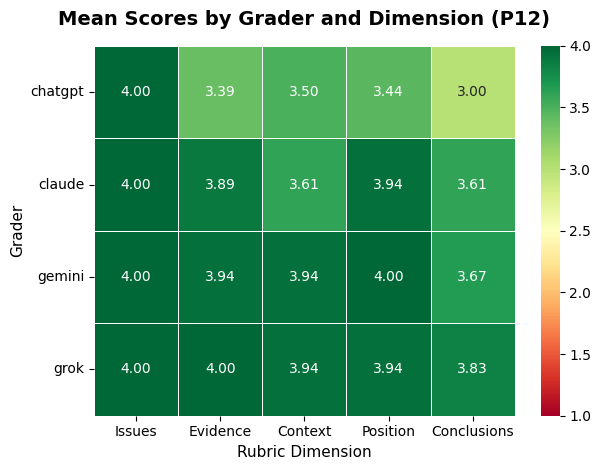

In [5]:
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=1,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

plt.title('Mean Scores by Grader and Dimension (P12)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rubric Dimension', fontsize=11)
plt.ylabel('Grader', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig('heatmap_grader_dimension_p12.png', dpi=150, bbox_inches='tight')
plt.show()

### Grading Scores in Cross-Model Evaluation

In [6]:
writers = ['chatgpt', 'claude', 'gemini', 'grok']
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

In [7]:
for p in p12_dataset['Prompt'].unique():
    subset = p12_dataset[p12_dataset['Prompt'] == p]
    print ("prompt", p)
    print(subset.groupby(['Assignment', 'EssayType']).size().to_string())

prompt p12
Assignment  EssayType
A1          generate     12
            tune         12
A2          generate     12
            tune         12
A3          generate     12
            tune         12


In [8]:
stats_df = metrics.compute_cross_grading_scores(p12_dataset, writers, dimensions, grader=None)
stats_df.tail(10)
len(stats_df)

#group by essaytype and writer and grader and dimension
# 2 essays x 2 writers x 4 graders x 5 dimensions = 160 rows 


160

In [9]:
grader_df = metrics.compute_cross_grading_scores(p12_dataset, writers, dimensions, grader="claude")

grader_df.head(20)

,EssayType,Writer,Grader,Dimension,N,Mean,Std,Bar_bottom,Bar_top,Values
0,generate,chatgpt,claude,Issues,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
1,generate,chatgpt,claude,Evidence,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
2,generate,chatgpt,claude,Context,3,3.3333,0.5774,2.7560,3.9107,"[3.0, 4.0, 3.0]"
3,generate,chatgpt,claude,Position,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
4,generate,chatgpt,claude,Conclusions,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
5,generate,claude,claude,Issues,0,NaN,0.0000,NaN,NaN,[]
6,generate,claude,claude,Evidence,0,NaN,0.0000,NaN,NaN,[]
7,generate,claude,claude,Context,0,NaN,0.0000,NaN,NaN,[]
8,generate,claude,claude,Position,0,NaN,0.0000,NaN,NaN,[]
9,generate,claude,claude,Conclusions,0,NaN,0.0000,NaN,NaN,[]


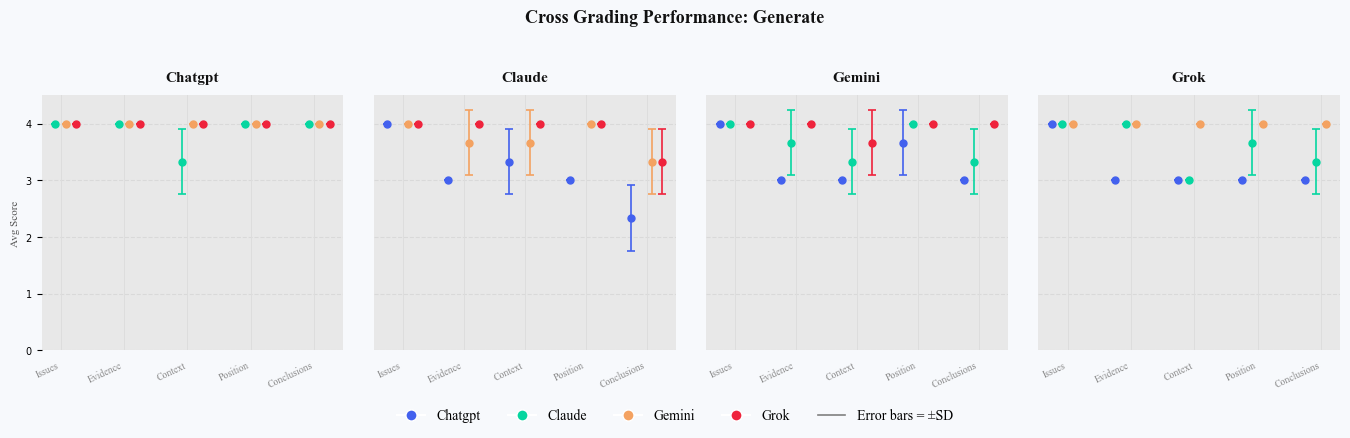

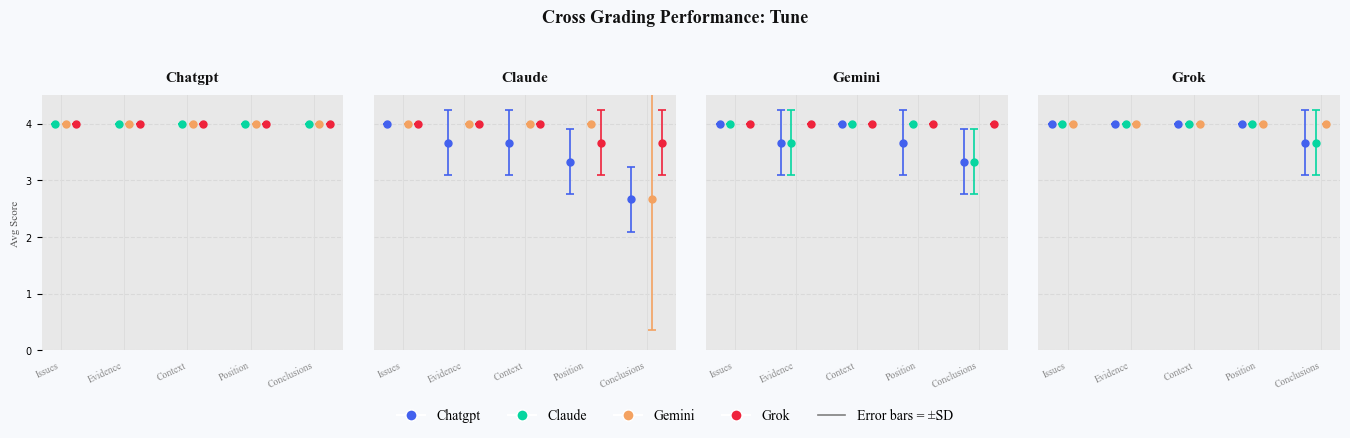

In [10]:
visualize.cross_grading_scores_by_essaytype(stats_df, writers, dimensions)

The chart highlights the grader bias models highlight through cross-evaluation.

- ChatGPT as grader is consistently lower.
- Gemini and Grok are consistently high and tight.
- Claude sits in between but shows more variance in all dimensions.

Analyze writer by writer:

ChatGPT (writer):
- In Generate, Claude grading shows large variance in Context.
- In Tune, everything tightens and rises.
- Interpretation: tuning stabilizes how others perceive ChatGPT’s structure.

Claude (writer):
- ChatGPT consistently penalizes Claude-written essays, and ChatGPT grading show variations for all of dimension unless the issue.
- For tuned essays, ChatGPT grades on evidence dimension at 3, not improving after tuned.

Gemini (writer):
- Both ChatGPT and Gemini show high grading variation in most dimensions.


Grok (writer):
-  Grok just gives 4.0 to all models no matter who wrote it.

### Writer Performance by Assignment 

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D 

In [12]:
assignment_bias = metrics.compute_grading_bias_by_assignment(p12_dataset, writers, dimensions)

assignment_bias.head(10)

len(assignment_bias)

#group by 2 essay types x 4 writers x 3 assignments x 5 dimensions = 120 rows

120

In [13]:
assignment_bias.head(20)

#Issues Caculation Example

#Consensus  = (4 + 3 + 4) / 3 = 3.67 

#Abs_Bias per grader:
  #Claude: |4 - 3.67| = 0.33
  #Gemini: |3 - 3.67| = 0.67  (rounded from 0.666...)
  #Grok:   |4 - 3.67| = 0.33

#Bias vector = [0.67, 0.33, 0.33]  

#Mean_AbsBias = (0.67 + 0.33 + 0.33) / 3 = 0.4444  

,Prompt,EssayType,Writer,Assignment,Dimension,N,AbsBiasValues,Consensus,Mean_AbsBias
0,p12,generate,chatgpt,A1,Issues,3,"[0.0, 0.0, 0.0]",4.00,0.0000
1,p12,generate,chatgpt,A1,Evidence,3,"[0.0, 0.0, 0.0]",4.00,0.0000
2,p12,generate,chatgpt,A1,Context,3,"[0.67, 0.33, 0.33]",3.67,0.4444
3,p12,generate,chatgpt,A1,Position,3,"[0.0, 0.0, 0.0]",4.00,0.0000
4,p12,generate,chatgpt,A1,Conclusions,3,"[0.0, 0.0, 0.0]",4.00,0.0000
5,p12,generate,chatgpt,A2,Issues,3,"[0.0, 0.0, 0.0]",4.00,0.0000
6,p12,generate,chatgpt,A2,Evidence,3,"[0.0, 0.0, 0.0]",4.00,0.0000
7,p12,generate,chatgpt,A2,Context,3,"[0.0, 0.0, 0.0]",4.00,0.0000
8,p12,generate,chatgpt,A2,Position,3,"[0.0, 0.0, 0.0]",4.00,0.0000
9,p12,generate,chatgpt,A2,Conclusions,3,"[0.0, 0.0, 0.0]",4.00,0.0000


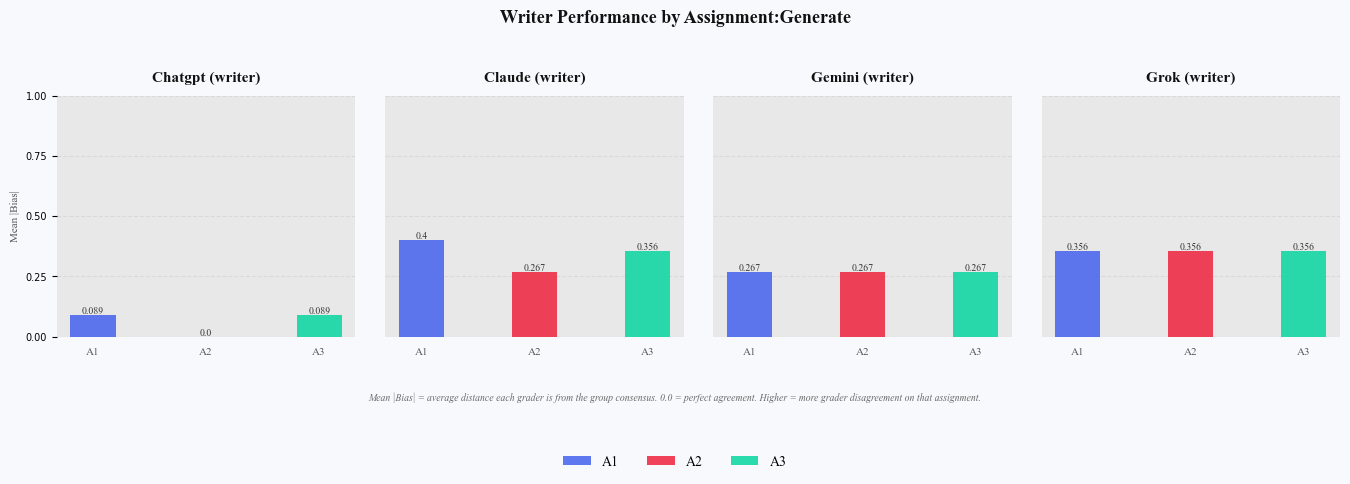

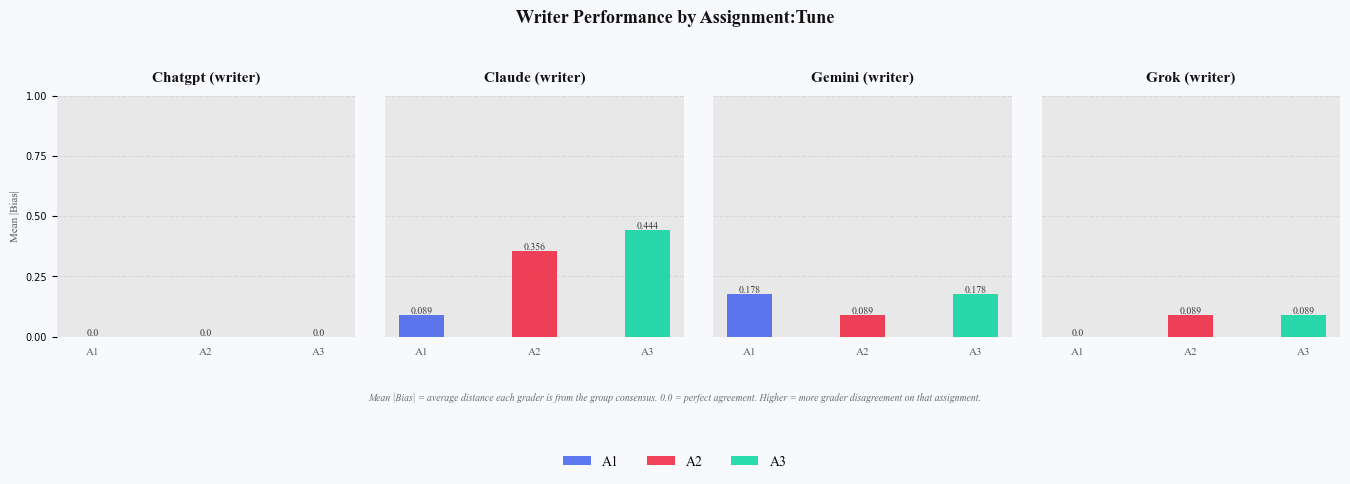

In [14]:
visualize.grading_bias_by_assignment(assignment_bias, writers, target_writer=None)

Generate essays:

- A3 is consistently the largest contributor.
- A2 is usually the smallest.

Tuned essays:

- Bias magnitude is roughly half (or less) of Generate.
- No extreme spikes like 0.53.
- Disagreement is more evenly distributed.

In [15]:
from scipy import stats

# Retrieve data
conclusions = assignment_bias[assignment_bias['Dimension'] == 'Conclusions']['Mean_AbsBias']
context = assignment_bias[assignment_bias['Dimension'] == 'Context']['Mean_AbsBias']
evidence = assignment_bias[assignment_bias['Dimension'] == 'Evidence']['Mean_AbsBias']
issues = assignment_bias[assignment_bias['Dimension'] == 'Issues']['Mean_AbsBias']
position = assignment_bias[assignment_bias['Dimension'] == 'Position']['Mean_AbsBias']


In [16]:
# P-value
conclusions_t, conclusions_p = stats.ttest_1samp(conclusions, popmean=0)
context_t, context_p = stats.ttest_1samp(context, popmean=0)
evidence_t, evidence_p = stats.ttest_1samp(evidence, popmean=0)
issues_t, issues_p = stats.ttest_1samp(issues, popmean=0)
position_t, position_p = stats.ttest_1samp(position, popmean=0)

In [17]:
results = {
    'Conclusions': (conclusions_t, conclusions_p),
    'Context':     (context_t,     context_p),
    'Evidence':    (evidence_t,    evidence_p),
    'Issues':      (issues_t,      issues_p),
    'Position':    (position_t,    position_p)
}

In [18]:
for dim, (t, p) in sorted(results.items(), key=lambda x: x[1][0]):

    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    
    print(dim, round(t, 2), round(p, 4), stars)

Context 4.05 0.0005 ***
Position 4.05 0.0005 ***
Evidence 4.41 0.0002 ***
Conclusions 5.86 0.0 ***
Issues nan nan ns


==> All 5 dimensions show statistically significant grader bias. Evidence is the hardest dimension for 4 AI models to grade on.

### Do two specific models grade differently by each dimension from each other?

In [19]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']
pair_names = ['Claude vs Gemini', 'Claude vs Grok', 'Claude vs ChatGPT',
              'Gemini vs Grok',   'Gemini vs ChatGPT', 'Grok vs ChatGPT']

In [20]:
rows = []

for dim in dimensions:
    for name, grader_a, grader_b in [
        ('Claude vs Gemini',  'claude',  'gemini'),
        ('Claude vs Grok',    'claude',  'grok'),
        ('Claude vs ChatGPT', 'claude',  'chatgpt'),
        ('Gemini vs Grok',    'gemini',  'grok'),
        ('Gemini vs ChatGPT', 'gemini',  'chatgpt'),
        ('Grok vs ChatGPT',   'grok',    'chatgpt'),
    ]:
        a = p12_dataset[p12_dataset['Grader'] == grader_a][dim].values
        b = p12_dataset[p12_dataset['Grader'] == grader_b][dim].values

        if np.std(a - b) == 0:
            p = 1.0
        else:
            t, p = stats.ttest_rel(a, b)
            p = round(p, 4)

        rows.append({'Pair': name, 'Dimension': dim, 'P_value': p})

In [21]:
results_df = pd.DataFrame(rows)
results_df

,Pair,Dimension,P_value
0,Claude vs Gemini,Issues,1.0000
1,Claude vs Grok,Issues,1.0000
2,Claude vs ChatGPT,Issues,1.0000
3,Gemini vs Grok,Issues,1.0000
4,Gemini vs ChatGPT,Issues,1.0000
5,Grok vs ChatGPT,Issues,1.0000
6,Claude vs Gemini,Evidence,0.3313
7,Claude vs Grok,Evidence,0.1631
8,Claude vs ChatGPT,Evidence,0.0007
9,Gemini vs Grok,Evidence,0.3313


In [22]:
pval_matrix  = results_df.pivot(index='Pair', columns='Dimension', values='P_value')

pval_matrix

Dimension,Conclusions,Context,Evidence,Issues,Position
Pair,,,,,
Claude vs ChatGPT,0.0116,0.1631,0.0007,1.0,0.0007
Claude vs Gemini,0.7903,0.0096,0.3313,1.0,0.3313
Claude vs Grok,0.1037,0.0096,0.1631,1.0,1.0000
Gemini vs ChatGPT,0.0236,0.0018,0.0002,1.0,0.0002
Gemini vs Grok,0.3808,1.0000,0.3313,1.0,0.3313
Grok vs ChatGPT,0.0001,0.0018,0.0001,1.0,0.0032


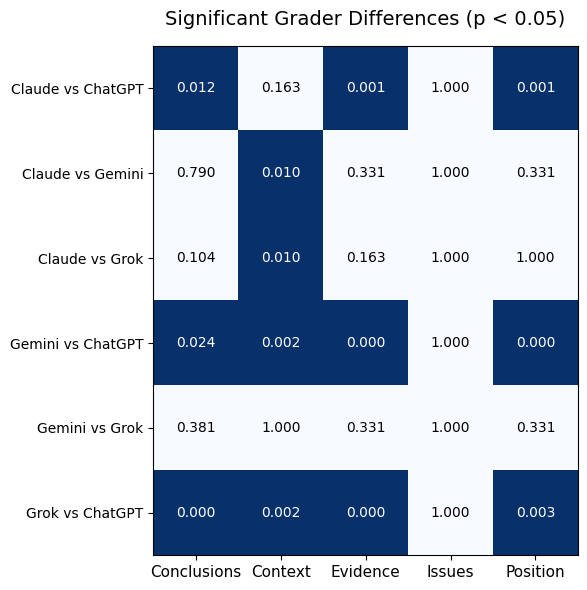

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))

# Create binary matrix: 1 = significant, 0 = not
binary_matrix = (pval_matrix.values.astype(float) < 0.05).astype(int)

for i in range(len(pval_matrix.index)):
    for j in range(len(pval_matrix.columns)):
        p = pval_matrix.iloc[i, j]
        color = 'white' if p < 0.05 else 'black'
        ax.text(j, i, f'{p:.3f}', ha='center', va='center', fontsize=10, color=color)

im = ax.imshow(binary_matrix, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(pval_matrix.columns)))
ax.set_xticklabels(pval_matrix.columns, fontsize=11)
ax.set_yticks(range(len(pval_matrix.index)))
ax.set_yticklabels(pval_matrix.index, fontsize=10)

ax.set_title('Significant Grader Differences (p < 0.05)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

- No pair shows significant difference on Issues.
- ChatGPT is the primary driver of grader disagreement, showing statistically significant differences from Claude, Gemini, and Grok across Evidence, Conclusions, and Position dimensions.
- Claude, Gemini, and Grok consistently gave similar scores to each other across all dimensions.